# Notebook 2 — Modèle multiplicatif : courbe de base × effet covariables (objectif : **courbes ER**)

## 1) Objectif final (livrable)
Produire et **visualiser des courbes d’ER** (évolution des remboursements anticipés en fonction de l’horizon), idéalement :
- une **courbe globale** (moyenne portefeuille),
- des **courbes par segments / profils** (ex : par quartiles de Tx, durée, montant, profil emprunteur),
- et éventuellement des **courbes prédites** vs **courbes observées** (backtest).

> ER peut être vue sous deux formes :
- **ER marginale** : part de RA “à l’instant / au mois t”  
- **ER cumulée** : somme des marginales jusqu’à l’horizon t (courbe la plus lisible et la plus demandée en restitution)

---

## 2) Contexte data : pourquoi un modèle “snapshot” est piégeux
La base est un **snapshot unique** : chaque contrat n’est observé qu’une fois, à un âge atteint `t_i`.

Deux biais structurels :
1. **Biais de survie / sélection**  
   Un contrat observé à `t=60` a forcément “survécu” 60 mois sans solder totalement → les observations à âge élevé sont conditionnées par la survie.
2. **Confusion âge–cohorte**  
   Les contrats anciens ont à la fois une `annee_origination` plus faible et un `AGE_PRET` plus élevé.  
   Si on met `AGE_PRET` (ou `ratio_avancement`) en feature libre, il capte l’essentiel du signal et écrase les autres variables.

Conséquence pratique observée :
- en incluant `AGE_PRET`, le modèle devient surtout “un modèle d’âge” et ne différencie pas bien les cohortes par caractéristiques.

---

## 3) Idée clé : séparer **effet âge pur** et **effet profil**
On veut une courbe ER en fonction du temps (l’âge) **et** un ajustement par caractéristiques.

On pose un modèle multiplicatif :

\[
\widehat{ER}(t, X) = g(t) \times \exp(\delta(X))
\]

- \(g(t)\) : **courbe de base** (effet âge pur) — estimée dans NB1 (agrégée, lissée, stable)
- \(\exp(\delta(X))\) : **multiplicateur de cohorte/profil** appris sur des covariables **fixes** du contrat (Tx, durée, montant, profil emprunteur…)

👉 Point important :
- `AGE_PRET` est **exclu** des features du modèle covariables.
- l’âge est entièrement porté par \(g(t)\).

---

## 4) Cible d’apprentissage : apprendre une “déviation” par rapport à la base
On construit une cible de type résidu log :

\[
\delta_i = \log\left(\frac{ER^{obs}_i}{g(t_i)} + \epsilon\right)
\]

Intuition :
- \(\delta > 0\) : le contrat prépaye **plus** que la moyenne à cet âge
- \(\delta < 0\) : il prépaye **moins** que la moyenne à cet âge

Le modèle (ex : LightGBM) apprend :
- \(\widehat{\delta}(X)\) à partir des features du contrat (sans âge)

Puis la prédiction finale :
\[
\widehat{ER}(t, X)= g(t)\times \exp(\widehat{\delta}(X))
\]

---

## 5) Pipeline concret (étapes)
### Étape A — Construire \(g(t)\) (courbe de base)
1. Agréger l’ER observée par âge (pondération EAD si pertinent)
2. Lisser \(g(t)\) pour éviter les pics (moyenne mobile, spline, isotonic, etc.)
3. Sauvegarder \(g(t)\) pour l’utiliser comme “offset” / base

### Étape B — Construire la cible \(\delta\)
1. Pour chaque observation i, récupérer \(t_i\) et \(ER^{obs}_i\)
2. Calculer \(g(t_i)\)
3. Construire \(\delta_i = \log(ER^{obs}_i / g(t_i) + \epsilon)\)
4. (Recommandé) clipper / winsoriser \(\delta\) pour limiter les extrêmes

### Étape C — Entraîner le modèle covariables (LightGBM)
- Features : Tx, durée, montant, profil emprunteur, etc.
- Target : \(\delta\)
- CV : idéalement par cohorte (année, trimestre d’origination…) pour limiter le leakage temporel

### Étape D — Générer des courbes ER prédites
Pour un profil \(X\) donné :
1. prédire \(\widehat{\delta}(X)\)
2. pour chaque âge t (1..T), calculer \(\widehat{ER}(t,X)=g(t)\exp(\widehat{\delta}(X))\)
3. tracer la courbe (et comparer à l’observé par segment si possible)

---

## 6) Visualisations attendues (le cœur du rendu)
### Courbe globale
- \(g(t)\) seule (baseline)

### Courbes segmentées (observé vs prédit)
Exemples :
- quartiles de Tx
- buckets de durée (ex : 10–15 ans, 15–20, 20+)
- tranches de montant
- catégories d’emprunteur (si dispo)

Pour chaque segment :
- **courbe observée** (moyenne segment, lissée)
- **courbe prédite** \(g(t)\exp(\widehat{\delta}(X_{segment}))\)

> Présentation recommandée :
- 1 figure = 1 segmentation (plus lisible)
- légende claire, même horizon, mêmes axes

---

## 7) Points d’attention (pour éviter les courbes “bizarres”)
- **Stabilité de \(g(t)\)** : si \(g(t)\) est trop petit au début, le ratio explose → \(\delta\) instable
- **Bornes** : ER doit rester dans \([0,1]\) (clip final si nécessaire)
- **Monotonie / pics** : si tu veux une courbe cumulée propre, il est souvent plus robuste de :
  - modéliser des **marginales ≥ 0**, puis cumuler
- **Validation** : éviter le split aléatoire pur si `annee_origination` structure fortement

---

## 8) Résultat attendu en une phrase
> Une **courbe ER(t)** globale stable \(g(t)\), et des **courbes ER(t) par profil** obtenues en multipliant \(g(t)\) par un facteur \(\exp(\widehat{\delta}(X))\), afin de visualiser comment les caractéristiques déplacent la courbe autour de la structure par terme moyenne.

## 1. Imports et configuration

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Bibliothèques chargées")

np.random.seed(14)

# Paramètres globaux
CUTOFF_TRAIN = '2021-01-01'   # Split temporel train / test
MAX_AGE_PROJ  = 36             # Horizon de projection (mois)

print("Bibliothèques chargées")


Bibliothèques chargées
Bibliothèques chargées


In [18]:
df = pd.read_csv("Export_ER_Agrege.csv", sep=";")

print(f"Dimensions : {df.shape}")
print(f"Nombre de prêts uniques : {df['ID'].nunique()}")
print(f"\nColonnes : {df.columns.tolist()}")

Dimensions : (63585, 25)
Nombre de prêts uniques : 63585

Colonnes : ['ID', 'AGE_CLI', 'B_MAT', 'B_RESMAT', 'CLASSACT', 'CSP', 'DARRET', 'E_OFF', 'MREVTOT', 'MTECH', 'NBIMP', 'NB_ECH', 'produit', 'RA', 'Tx', 'EAD', 'AGE_PRET', 'HORIZON_RES', 'CSP_grp', 'CRD', 'ER_obs', 'FLAG_ER', 'Capital_initial', 'Date_origination', 'Cohorte']


In [19]:

# --- CASE 2E: checks (sans drop, on regarde la qualité) ---
print("Rows:", len(df))
print("AGE_PRET: NaN% =", df["AGE_PRET"].isna().mean(), "| min/max =", df["AGE_PRET"].min(), df["AGE_PRET"].max())
print("CRD: NaN% =", df["CRD"].isna().mean(), "| <=0% =", (df["CRD"] <= 0).mean())
print("ER_obs: NaN% =", df["ER_obs"].isna().mean(), "| mean =", df["ER_obs"].mean())
print("Date_origination: NaT% =", df["Date_origination"].isna().mean())

display(df[["DARRET","Date_origination","B_MAT","B_RESMAT","AGE_PRET","MTECH","RA","CRD","ER_obs"]].head(10))

Rows: 63585
AGE_PRET: NaN% = 0.0 | min/max = 0.0 165.0
CRD: NaN% = 0.0 | <=0% = 0.0
ER_obs: NaN% = 0.0 | mean = 0.9163963849182699
Date_origination: NaT% = 0.0


,DARRET,Date_origination,B_MAT,B_RESMAT,AGE_PRET,MTECH,RA,CRD,ER_obs
0,2019-01-01,2015-02-21,61.0,14.0,47.0,144.99,1631.48,398.38,1.0
1,2019-01-01,2015-09-19,48.0,8.0,40.0,247.04,1802.36,173.96,1.0
2,2019-01-01,2015-09-19,48.0,8.0,40.0,123.52,902.49,85.67,1.0
3,2019-01-01,2015-12-18,49.0,12.0,37.0,180.03,2123.00,37.36,1.0
4,2019-01-01,2016-09-13,73.0,45.0,28.0,469.66,15330.12,5804.58,1.0
5,2019-01-01,2016-11-12,48.0,22.0,26.0,111.66,2383.94,72.58,1.0
6,2019-01-01,2017-02-10,70.0,47.0,23.0,348.88,12849.91,3547.45,1.0
7,2019-01-01,2017-03-12,49.0,27.0,22.0,213.85,4706.45,1067.50,1.0
8,2019-01-01,2017-05-11,72.0,52.0,20.0,113.53,4668.00,1235.56,1.0
9,2019-01-01,2017-06-10,48.0,29.0,19.0,148.22,4224.00,74.38,1.0


df_mod rows: 63585
g rows: 154


,AGE_PRET,g_t,g_t_smooth
0,0.0,0.363580,0.458828
1,1.0,0.404571,0.482606
2,2.0,0.608333,0.508903
3,3.0,0.553938,0.573161
4,4.0,0.614094,0.622078
5,5.0,0.684867,0.626401
6,6.0,0.649157,0.634319
7,7.0,0.629949,0.638858
8,8.0,0.593527,0.645160
9,9.0,0.636792,0.651149


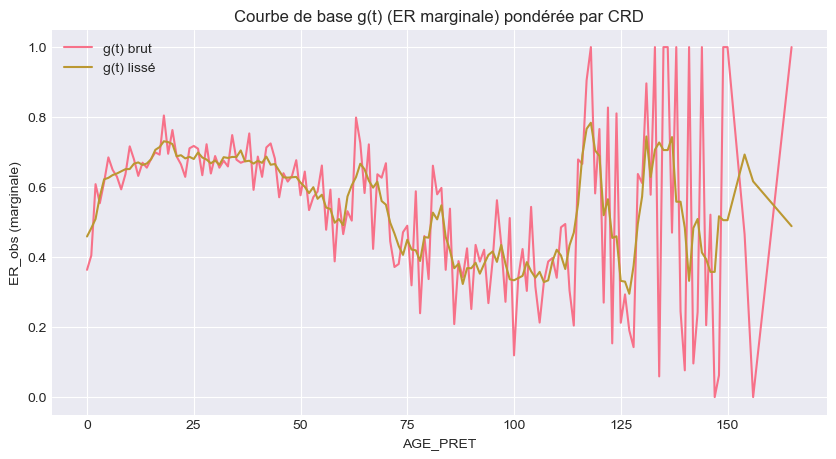

In [20]:
import matplotlib.pyplot as plt

# --- CASE 3A: vue modeling (on filtre seulement ici) ---
df_mod = df.loc[
    df["AGE_PRET"].notna()
    & df["ER_obs"].notna()
    & df["CRD"].notna()
    & (df["CRD"] > 0)
].copy()

print("df_mod rows:", len(df_mod))

# --- CASE 3B: g(t) = moyenne pondérée de ER_obs, poids = CRD ---
df_mod["w"] = df_mod["CRD"]
df_mod["num"] = df_mod["ER_obs"] * df_mod["w"]

g = (
    df_mod.groupby("AGE_PRET")[["num", "w"]]
          .sum()
          .assign(g_t=lambda d: d["num"] / d["w"])
          .reset_index()[["AGE_PRET", "g_t"]]
          .sort_values("AGE_PRET")
)

# lissage simple
g["g_t_smooth"] = g["g_t"].rolling(window=5, center=True, min_periods=1).mean()

print("g rows:", len(g))
display(g.head(10))

# --- CASE 3C: plot baseline ---
plt.figure(figsize=(10,5))
plt.plot(g["AGE_PRET"], g["g_t"], label="g(t) brut")
plt.plot(g["AGE_PRET"], g["g_t_smooth"], label="g(t) lissé")
plt.title("Courbe de base g(t) (ER marginale) pondérée par CRD")
plt.xlabel("AGE_PRET")
plt.ylabel("ER_obs (marginale)")
plt.grid(True)
plt.legend()
plt.show()

Seuil expo: 68300.96889999999
Ages gardés: 0 -> 110 | nb ages: 107


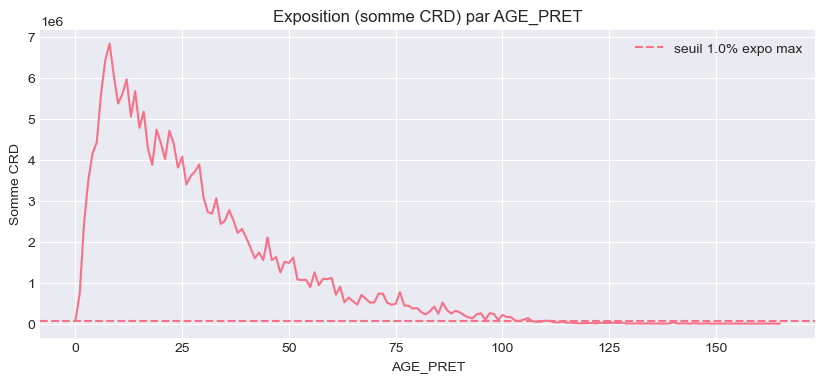

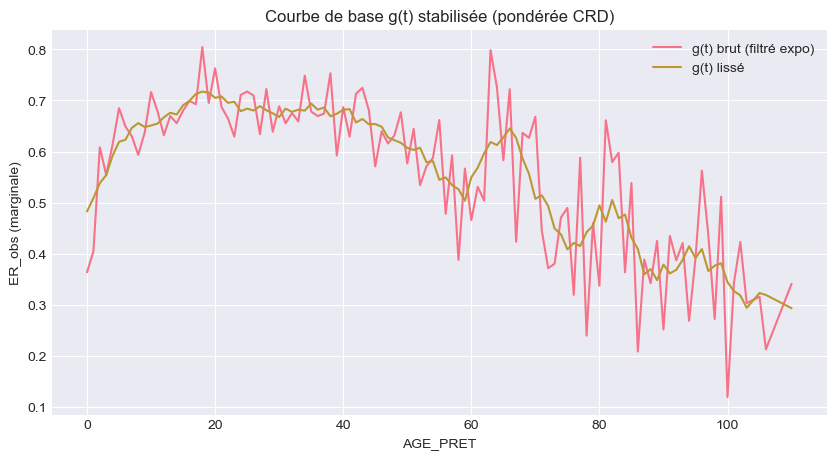

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Exposition totale par âge (poids = CRD)
expo = (
    df_mod.groupby("AGE_PRET")["CRD"]
          .sum()
          .reset_index(name="expo_CRD")
          .sort_values("AGE_PRET")
)

# seuil : on garde les âges dont l'expo est au moins p% de l'expo max
p = 0.01   # 1% (tu peux tester 0.5% ou 2%)
threshold = p * expo["expo_CRD"].max()

valid_ages = expo.loc[expo["expo_CRD"] >= threshold, "AGE_PRET"]

print("Seuil expo:", threshold)
print("Ages gardés:", int(valid_ages.min()), "->", int(valid_ages.max()), "| nb ages:", valid_ages.nunique())

# Recalcule g(t) uniquement sur ces âges
df_g = df_mod[df_mod["AGE_PRET"].isin(valid_ages)].copy()
df_g["w"] = df_g["CRD"]
df_g["num"] = df_g["ER_obs"] * df_g["w"]

g = (
    df_g.groupby("AGE_PRET")[["num", "w"]]
        .sum()
        .assign(g_t=lambda d: d["num"] / d["w"])
        .reset_index()[["AGE_PRET", "g_t"]]
        .sort_values("AGE_PRET")
)

g["g_t_smooth"] = g["g_t"].rolling(window=7, center=True, min_periods=1).mean()

# --- Plot expo ---
plt.figure(figsize=(10,4))
plt.plot(expo["AGE_PRET"], expo["expo_CRD"])
plt.axhline(threshold, linestyle="--", label=f"seuil {p*100:.1f}% expo max")
plt.title("Exposition (somme CRD) par AGE_PRET")
plt.xlabel("AGE_PRET")
plt.ylabel("Somme CRD")
plt.grid(True)
plt.legend()
plt.show()

# --- Plot g(t) stabilisée ---
plt.figure(figsize=(10,5))
plt.plot(g["AGE_PRET"], g["g_t"], label="g(t) brut (filtré expo)")
plt.plot(g["AGE_PRET"], g["g_t_smooth"], label="g(t) lissé")
plt.title("Courbe de base g(t) stabilisée (pondérée CRD)")
plt.xlabel("AGE_PRET")
plt.ylabel("ER_obs (marginale)")
plt.grid(True)
plt.legend()
plt.show()

In [22]:
import numpy as np
import pandas as pd

# Map g(t) lissée dans df_g (dataset modeling)
g_map = g.set_index("AGE_PRET")["g_t_smooth"]
df_g["g_t"] = df_g["AGE_PRET"].map(g_map)

# delta
eps = 1e-6
df_g["delta"] = np.log(df_g["ER_obs"] / (df_g["g_t"] + eps) + eps)

# clipping pour stabilité
lo, hi = df_g["delta"].quantile([0.01, 0.99])
df_g["delta_clip"] = df_g["delta"].clip(lo, hi)

print(df_g["delta_clip"].describe())

count    63205.000000
mean         0.052448
std          1.742039
min        -13.815511
25%          0.363218
50%          0.391574
75%          0.433683
max          0.893776
Name: delta_clip, dtype: float64


In [23]:
df_g = df_g.sort_values("Date_origination")
cut = int(0.8 * len(df_g))

train_idx = df_g.index[:cut]
test_idx  = df_g.index[cut:]

# Features (à adapter mais on évite RA/CRD/ER_obs/AGE_PRET)
num_cols = [c for c in ["Tx", "MREVTOT", "MTECH", "B_MAT"] if c in df_g.columns]
cat_cols = [c for c in ["CLASSACT", "CSP"] if c in df_g.columns]

X = df_g[num_cols + cat_cols].copy()
y = df_g["delta_clip"].copy()

for c in cat_cols:
    X[c] = X[c].astype("category")

X_train, y_train = X.loc[train_idx], y.loc[train_idx]
X_test,  y_test  = X.loc[test_idx],  y.loc[test_idx]

print("train:", X_train.shape, "| test:", X_test.shape)

train: (50564, 6) | test: (12641, 6)


In [25]:
import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

model = LGBMRegressor(
    n_estimators=1500,
    learning_rate=0.03,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric="l1",
    callbacks=[lgb.log_evaluation(200)]
)

delta_pred = model.predict(X_test)
print("MAE(delta):", mean_absolute_error(y_test, delta_pred))
print("RMSE(delta):", mean_squared_error(y_test, delta_pred))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001109 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 956
[LightGBM] [Info] Number of data points in the train set: 50564, number of used features: 6
[LightGBM] [Info] Start training from score 0.047309
[200]	valid_0's l1: 0.651529	valid_0's l2: 2.54905
[400]	valid_0's l1: 0.656348	valid_0's l2: 2.57615
[600]	valid_0's l1: 0.665115	valid_0's l2: 2.60098
[800]	valid_0's l1: 0.670622	valid_0's l2: 2.62061
[1000]	valid_0's l1: 0.677504	valid_0's l2: 2.64135
[1200]	valid_0's l1: 0.682226	valid_0's l2: 2.65991
[1400]	valid_0's l1: 0.688468	valid_0's l2: 2.67852
MAE(delta): 0.6900647697911562
RMSE(delta): 2.6878749932933634


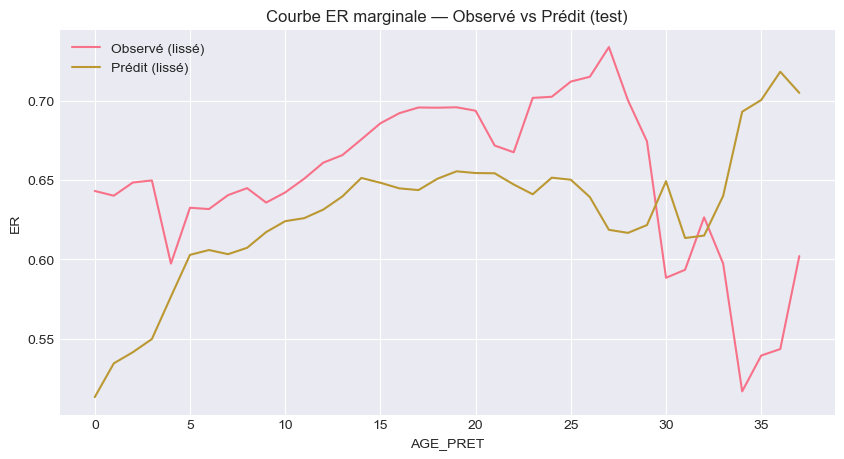

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df_test = df_g.loc[test_idx].copy()
df_test["delta_hat"] = delta_pred
df_test["ER_hat"] = (df_test["g_t"] * np.exp(df_test["delta_hat"])).clip(0, 1)

# courbes moyennes par âge (pondérées CRD)
def wavg(v, w):
    return np.sum(v*w) / np.sum(w)

curves = (
    df_test.groupby("AGE_PRET")
           .apply(lambda x: pd.Series({
               "ER_obs": wavg(x["ER_obs"].values, x["CRD"].values),
               "ER_hat": wavg(x["ER_hat"].values, x["CRD"].values),
               "expo":  x["CRD"].sum()
           }))
           .reset_index()
           .sort_values("AGE_PRET")
)

curves["ER_obs_s"] = curves["ER_obs"].rolling(7, center=True, min_periods=1).mean()
curves["ER_hat_s"] = curves["ER_hat"].rolling(7, center=True, min_periods=1).mean()

plt.figure(figsize=(10,5))
plt.plot(curves["AGE_PRET"], curves["ER_obs_s"], label="Observé (lissé)")
plt.plot(curves["AGE_PRET"], curves["ER_hat_s"], label="Prédit (lissé)")
plt.title("Courbe ER marginale — Observé vs Prédit (test)")
plt.xlabel("AGE_PRET")
plt.ylabel("ER")
plt.grid(True)
plt.legend()
plt.show()

In [28]:
id="x2b8m1"
T_MAX = 30
df_g30 = df_g[df_g["AGE_PRET"] <= T_MAX].copy()

df_g30 = df_g30.sort_values("Date_origination")
cut = int(0.8 * len(df_g30))
train_idx = df_g30.index[:cut]
test_idx  = df_g30.index[cut:]

num_cols = [c for c in ["Tx", "MREVTOT", "MTECH", "B_MAT"] if c in df_g30.columns]
cat_cols = [c for c in ["CLASSACT", "CSP"] if c in df_g30.columns]

X = df_g30[num_cols + cat_cols].copy()
y = df_g30["delta_clip"].copy()

for c in cat_cols:
    X[c] = X[c].astype("category")

X_train, y_train = X.loc[train_idx], y.loc[train_idx]
X_test,  y_test  = X.loc[test_idx],  y.loc[test_idx]

import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

model = LGBMRegressor(
    n_estimators=1500,
    learning_rate=0.03,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric="l1",
    callbacks=[lgb.log_evaluation(200)]
)

delta_pred = model.predict(X_test)
print("MAE(delta):", mean_absolute_error(y_test, delta_pred))
print("RMSE(delta):", mean_squared_error(y_test, delta_pred))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000556 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 956
[LightGBM] [Info] Number of data points in the train set: 33540, number of used features: 6
[LightGBM] [Info] Start training from score 0.070100
[200]	valid_0's l1: 0.635051	valid_0's l2: 2.41229
[400]	valid_0's l1: 0.636013	valid_0's l2: 2.43645
[600]	valid_0's l1: 0.639653	valid_0's l2: 2.45772
[800]	valid_0's l1: 0.642855	valid_0's l2: 2.48049
[1000]	valid_0's l1: 0.646144	valid_0's l2: 2.49888
[1200]	valid_0's l1: 0.650972	valid_0's l2: 2.51765
[1400]	valid_0's l1: 0.655768	valid_0's l2: 2.53161
MAE(delta): 0.6580261937004758
RMSE(delta): 2.5383676893401863


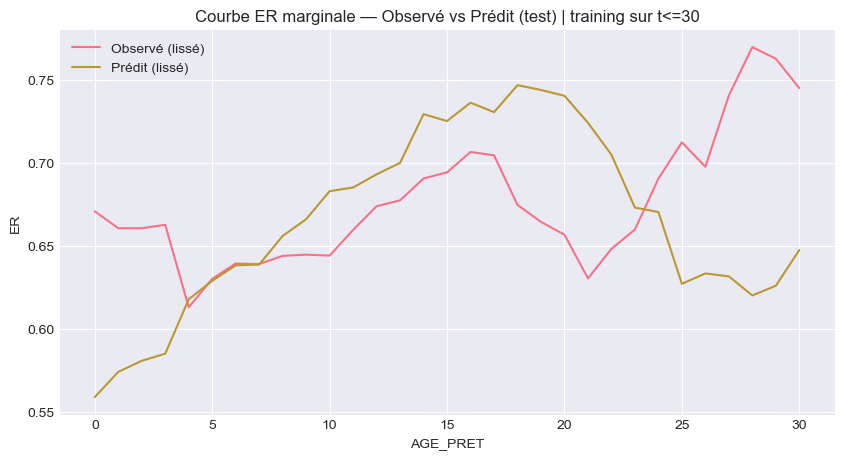

In [29]:
id="d8h6s4"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_test = df_g30.loc[test_idx].copy()
df_test["delta_hat"] = delta_pred
df_test["ER_hat"] = (df_test["g_t"] * np.exp(df_test["delta_hat"])).clip(0, 1)

def wavg(v, w):
    return np.sum(v*w) / np.sum(w)

curves = (
    df_test.groupby("AGE_PRET")
           .apply(lambda x: pd.Series({
               "ER_obs": wavg(x["ER_obs"].values, x["CRD"].values),
               "ER_hat": wavg(x["ER_hat"].values, x["CRD"].values),
               "expo":  x["CRD"].sum()
           }))
           .reset_index()
           .sort_values("AGE_PRET")
)

curves["ER_obs_s"] = curves["ER_obs"].rolling(7, center=True, min_periods=1).mean()
curves["ER_hat_s"] = curves["ER_hat"].rolling(7, center=True, min_periods=1).mean()

plt.figure(figsize=(10,5))
plt.plot(curves["AGE_PRET"], curves["ER_obs_s"], label="Observé (lissé)")
plt.plot(curves["AGE_PRET"], curves["ER_hat_s"], label="Prédit (lissé)")
plt.title("Courbe ER marginale — Observé vs Prédit (test) | training sur t<=30")
plt.xlabel("AGE_PRET")
plt.ylabel("ER")
plt.grid(True)
plt.legend()
plt.show()

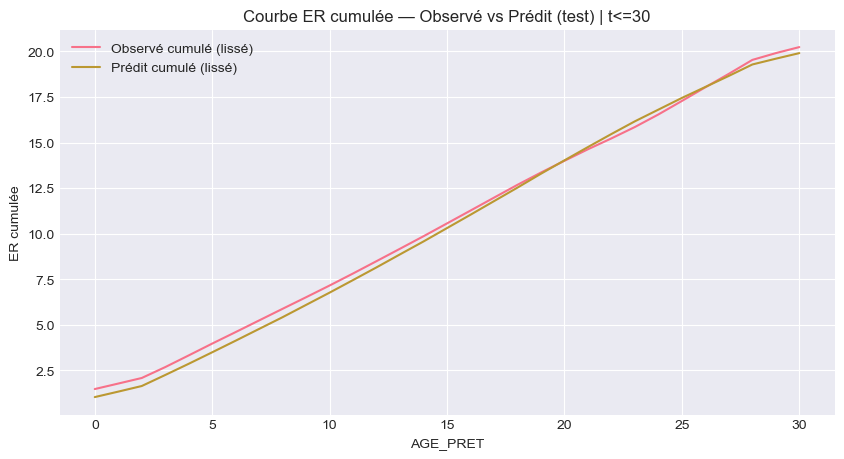

In [30]:
id="w0n8m6"
curves["ER_obs_cum"] = curves["ER_obs"].cumsum()
curves["ER_hat_cum"] = curves["ER_hat"].cumsum()

curves["ER_obs_cum_s"] = curves["ER_obs_cum"].rolling(5, center=True, min_periods=1).mean()
curves["ER_hat_cum_s"] = curves["ER_hat_cum"].rolling(5, center=True, min_periods=1).mean()

plt.figure(figsize=(10,5))
plt.plot(curves["AGE_PRET"], curves["ER_obs_cum_s"], label="Observé cumulé (lissé)")
plt.plot(curves["AGE_PRET"], curves["ER_hat_cum_s"], label="Prédit cumulé (lissé)")
plt.title("Courbe ER cumulée — Observé vs Prédit (test) | t<=30")
plt.xlabel("AGE_PRET")
plt.ylabel("ER cumulée")
plt.grid(True)
plt.legend()
plt.show()

In [31]:
# CASE A1 — split d'abord (sur df_mod, t<=30)
T_MAX = 30
df30 = df_mod[df_mod["AGE_PRET"] <= T_MAX].copy()
df30 = df30.sort_values("Date_origination")

cut = int(0.8 * len(df30))
df_train = df30.iloc[:cut].copy()
df_test  = df30.iloc[cut:].copy()

print("train:", df_train.shape, "test:", df_test.shape)

train: (33540, 27) test: (8385, 27)


In [32]:
# CASE A2 — g(t) sur train uniquement (pondérée CRD)
df_train["w"] = df_train["CRD"]
df_train["num"] = df_train["ER_obs"] * df_train["w"]

g_train = (
    df_train.groupby("AGE_PRET")[["num","w"]].sum()
            .assign(g_t=lambda d: d["num"]/d["w"])
            .reset_index()[["AGE_PRET","g_t"]]
            .sort_values("AGE_PRET")
)
g_train["g_t_smooth"] = g_train["g_t"].rolling(7, center=True, min_periods=1).mean()

gmap = g_train.set_index("AGE_PRET")["g_t_smooth"]
df_train["g_t"] = df_train["AGE_PRET"].map(gmap)
df_test["g_t"]  = df_test["AGE_PRET"].map(gmap)

print("NaN g_t train/test:", df_train["g_t"].isna().mean(), df_test["g_t"].isna().mean())

NaN g_t train/test: 0.0 0.0


In [33]:
# CASE A3 — delta sur train/test cohérents
import numpy as np

eps = 1e-6
for d in [df_train, df_test]:
    d["delta"] = np.log(d["ER_obs"] / (d["g_t"] + eps) + eps)

lo, hi = df_train["delta"].quantile([0.01, 0.99])
df_train["delta_clip"] = df_train["delta"].clip(lo, hi)
df_test["delta_clip"]  = df_test["delta"].clip(lo, hi)

In [34]:
import lightgbm as lgb
from lightgbm import LGBMRegressor

num_cols = [c for c in ["Tx", "MREVTOT", "MTECH", "B_MAT"] if c in df_train.columns]
cat_cols = [c for c in ["CLASSACT", "CSP"] if c in df_train.columns]

X_train = df_train[num_cols + cat_cols].copy()
y_train = df_train["delta_clip"].copy()
w_train = df_train["CRD"].copy()

X_test = df_test[num_cols + cat_cols].copy()
y_test = df_test["delta_clip"].copy()
w_test = df_test["CRD"].copy()

for c in cat_cols:
    X_train[c] = X_train[c].astype("category")
    X_test[c]  = X_test[c].astype("category")

model = LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(
    X_train, y_train,
    sample_weight=w_train,
    eval_set=[(X_test, y_test)],
    eval_sample_weight=[w_test],
    eval_metric="l1",
    callbacks=[lgb.log_evaluation(200)]
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000568 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 956
[LightGBM] [Info] Number of data points in the train set: 33540, number of used features: 6
[LightGBM] [Info] Start training from score -1.189892
[200]	valid_0's l1: 1.80251	valid_0's l2: 8.82077
[400]	valid_0's l1: 1.78202	valid_0's l2: 9.05418
[600]	valid_0's l1: 1.77404	valid_0's l2: 9.19751
[800]	valid_0's l1: 1.76497	valid_0's l2: 9.30466
[1000]	valid_0's l1: 1.76527	valid_0's l2: 9.42696
[1200]	valid_0's l1: 1.76317	valid_0's l2: 9.52698
[1400]	valid_0's l1: 1.75809	valid_0's l2: 9.57873
[1600]	valid_0's l1: 1.75773	valid_0's l2: 9.67028
[1800]	valid_0's l1: 1.75771	valid_0's l2: 9.73728
[2000]	valid_0's l1: 1.75856	valid_0's l2: 9.78501


,boosting_type,'gbdt'
,num_leaves,63
,max_depth,-1
,learning_rate,0.03
,n_estimators,2000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [35]:
# Buckets d'âge (ex: 0-5, 6-10, 11-15, 16-20, 21-30)
bins = [0,5,10,15,20,30]
labels = ["0-5","6-10","11-15","16-20","21-30"]

df_train["t_bin"] = pd.cut(df_train["AGE_PRET"], bins=bins, labels=labels, include_lowest=True)
df_test["t_bin"]  = pd.cut(df_test["AGE_PRET"],  bins=bins, labels=labels, include_lowest=True)

# On ajoute t_bin comme catégorielle (c'est un proxy temps contrôlé, pas AGE_PRET brut)
X_train2 = X_train.copy()
X_test2  = X_test.copy()
X_train2["t_bin"] = df_train["t_bin"].astype("category")
X_test2["t_bin"]  = df_test["t_bin"].astype("category")

model2 = LGBMRegressor(
    n_estimators=2500,
    learning_rate=0.03,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model2.fit(
    X_train2, y_train,
    sample_weight=w_train,
    eval_set=[(X_test2, y_test)],
    eval_sample_weight=[w_test],
    eval_metric="l1",
    callbacks=[lgb.log_evaluation(200)]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000353 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 961
[LightGBM] [Info] Number of data points in the train set: 33540, number of used features: 7
[LightGBM] [Info] Start training from score -1.189892
[200]	valid_0's l1: 1.80997	valid_0's l2: 8.94102
[400]	valid_0's l1: 1.79084	valid_0's l2: 9.19277
[600]	valid_0's l1: 1.77878	valid_0's l2: 9.38078
[800]	valid_0's l1: 1.77324	valid_0's l2: 9.52942
[1000]	valid_0's l1: 1.76535	valid_0's l2: 9.6216
[1200]	valid_0's l1: 1.76095	valid_0's l2: 9.69107
[1400]	valid_0's l1: 1.75834	valid_0's l2: 9.7635
[1600]	valid_0's l1: 1.75444	valid_0's l2: 9.82532
[1800]	valid_0's l1: 1.75557	valid_0's l2: 9.87262
[2000]	valid_0's l1: 1.75613	valid_0's l2: 9.91403
[2200]	valid_0's l1: 1.75719	valid_0's l2: 9.95549
[2400]	valid_0's l1: 1.7586	valid_0's l2

,boosting_type,'gbdt'
,num_leaves,63
,max_depth,-1
,learning_rate,0.03
,n_estimators,2500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


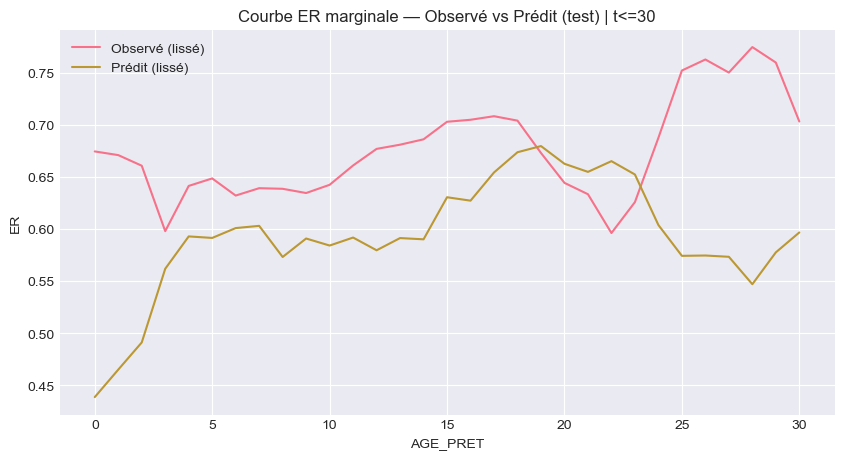

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_plot = df_test.copy()
df_plot["delta_hat"] = model2.predict(X_test2)
df_plot["ER_hat"] = (df_plot["g_t"] * np.exp(df_plot["delta_hat"])).clip(0,1)

def wavg(v,w): return (v*w).sum()/w.sum()

curves = (
    df_plot.groupby("AGE_PRET")
           .apply(lambda x: pd.Series({
               "ER_obs": wavg(x["ER_obs"], x["CRD"]),
               "ER_hat": wavg(x["ER_hat"], x["CRD"]),
           }))
           .reset_index()
           .sort_values("AGE_PRET")
)

curves["ER_obs_s"] = curves["ER_obs"].rolling(5, center=True, min_periods=1).mean()
curves["ER_hat_s"] = curves["ER_hat"].rolling(5, center=True, min_periods=1).mean()

plt.figure(figsize=(10,5))
plt.plot(curves["AGE_PRET"], curves["ER_obs_s"], label="Observé (lissé)")
plt.plot(curves["AGE_PRET"], curves["ER_hat_s"], label="Prédit (lissé)")
plt.title("Courbe ER marginale — Observé vs Prédit (test) | t<=30")
plt.xlabel("AGE_PRET")
plt.ylabel("ER")
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
import numpy as np
import pandas as pd

# On repart de tes objets df_train/df_test et gmap (g(t) train-only)
# Si tu ne les as plus, dis-le et je te donne la case pour les reconstruire.

# 1) Baseline g(t)
df_test = df_test.copy()
df_test["ER_base"] = df_test["g_t"].clip(0,1)

# 2) Modèle (celui que tu viens d'entraîner) -> ER_hat déjà calculé sinon :
# df_test["ER_hat"] = (df_test["g_t"] * np.exp(df_test["delta_hat"])).clip(0,1)

# 3) Oracle segment ultra simple : buckets Tx -> delta moyen par bucket
# (si Tx existe)
df_test["Tx_num"] = pd.to_numeric(df_test["Tx"], errors="coerce")
df_train["Tx_num"] = pd.to_numeric(df_train["Tx"], errors="coerce")

df_train["tx_bin"] = pd.qcut(df_train["Tx_num"], 5, duplicates="drop")
df_test["tx_bin"]  = pd.qcut(df_test["Tx_num"], 5, duplicates="drop")

# delta "observé" sur train
eps = 1e-6
df_train["delta_obs"] = np.log(df_train["ER_obs"] / (df_train["g_t"] + eps) + eps)

# moyenne pondérée (CRD) du delta par bucket
def wavg(v,w): return (v*w).sum()/w.sum()

delta_by_bin = (
    df_train.groupby("tx_bin")
            .apply(lambda x: wavg(x["delta_obs"], x["CRD"]))
)

df_test["delta_oracle_tx"] = df_test["tx_bin"].map(delta_by_bin).fillna(0.0)
df_test["ER_oracle_tx"] = (df_test["g_t"] * np.exp(df_test["delta_oracle_tx"])).clip(0,1)

# métrique pondérée sur ER (CRD)
def wmae(y, yhat, w):
    return (np.abs(y-yhat)*w).sum()/w.sum()

w = df_test["CRD"].values
y = df_test["ER_obs"].values

print("WMAE baseline g(t):", wmae(y, df_test["ER_base"].values, w))
print("WMAE oracle Tx-bin :", wmae(y, df_test["ER_oracle_tx"].values, w))
# si tu as ER_hat :
if "ER_hat" in df_test.columns:
    print("WMAE modèle LGBM   :", wmae(y, df_test["ER_hat"].values, w))

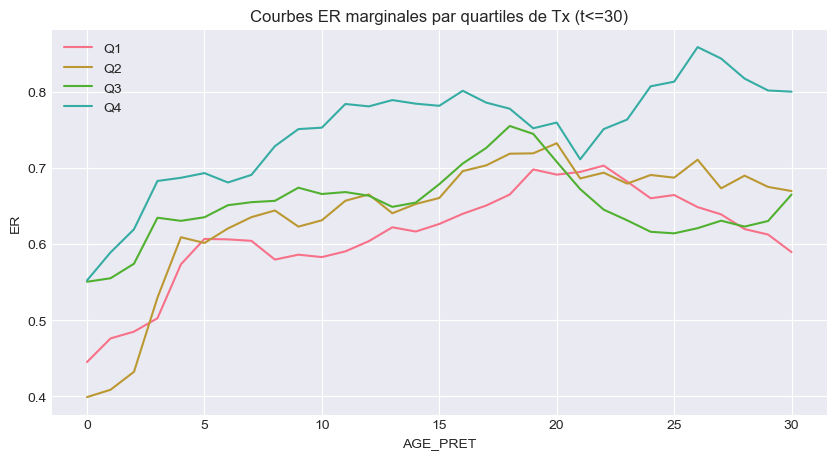

In [37]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

T_MAX = 30
d = df_mod[df_mod["AGE_PRET"] <= T_MAX].copy()
d["Tx_num"] = pd.to_numeric(d["Tx"], errors="coerce")
d = d.dropna(subset=["Tx_num"])

d["tx_q"] = pd.qcut(d["Tx_num"], 4, labels=["Q1","Q2","Q3","Q4"])

def wavg(v,w): return (v*w).sum()/w.sum()

curves_seg = (
    d.groupby(["tx_q","AGE_PRET"])
     .apply(lambda x: wavg(x["ER_obs"], x["CRD"]))
     .rename("ER")
     .reset_index()
     .sort_values("AGE_PRET")
)

plt.figure(figsize=(10,5))
for q, sub in curves_seg.groupby("tx_q"):
    sub = sub.sort_values("AGE_PRET")
    sub["ER_s"] = sub["ER"].rolling(5, center=True, min_periods=1).mean()
    plt.plot(sub["AGE_PRET"], sub["ER_s"], label=str(q))

plt.title("Courbes ER marginales par quartiles de Tx (t<=30)")
plt.xlabel("AGE_PRET")
plt.ylabel("ER")
plt.grid(True)
plt.legend()
plt.show()

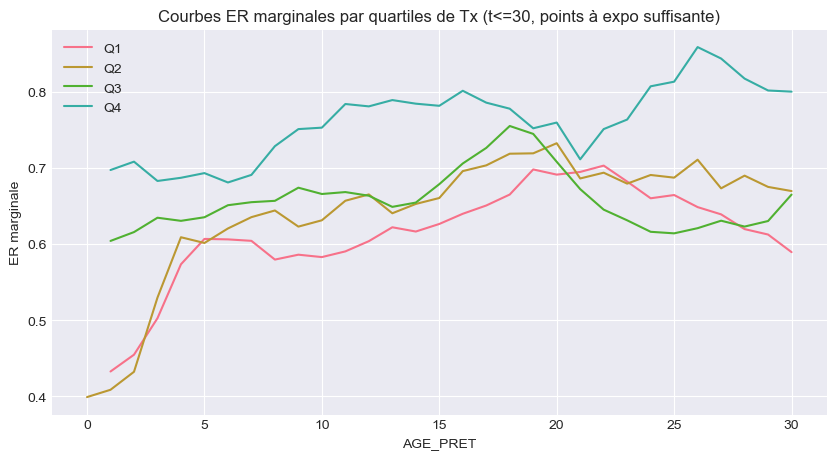

Seuil expo: 25549.392399999997


In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

T_MAX = 30
d = df_mod[df_mod["AGE_PRET"] <= T_MAX].copy()
d["Tx_num"] = pd.to_numeric(d["Tx"], errors="coerce")
d = d.dropna(subset=["Tx_num"])

d["tx_q"] = pd.qcut(d["Tx_num"], 4, labels=["Q1","Q2","Q3","Q4"])

def wavg(v,w): 
    return (v*w).sum()/w.sum()

# ER + expo par (segment, age)
agg = (
    d.groupby(["tx_q","AGE_PRET"])
     .apply(lambda x: pd.Series({
         "ER": wavg(x["ER_obs"], x["CRD"]),
         "expo": x["CRD"].sum()
     }))
     .reset_index()
     .sort_values("AGE_PRET")
)

# filtre expo minimale par point (évite les âges “bruit” même <=30)
expo_thr = 0.01 * agg["expo"].max()   # 1% de l'expo max globale
agg_f = agg[agg["expo"] >= expo_thr].copy()

plt.figure(figsize=(10,5))
for q, sub in agg_f.groupby("tx_q"):
    sub = sub.sort_values("AGE_PRET")
    sub["ER_s"] = sub["ER"].rolling(5, center=True, min_periods=1).mean()
    plt.plot(sub["AGE_PRET"], sub["ER_s"], label=f"{q}")

plt.title("Courbes ER marginales par quartiles de Tx (t<=30, points à expo suffisante)")
plt.xlabel("AGE_PRET")
plt.ylabel("ER marginale")
plt.grid(True)
plt.legend()
plt.show()

print("Seuil expo:", expo_thr)

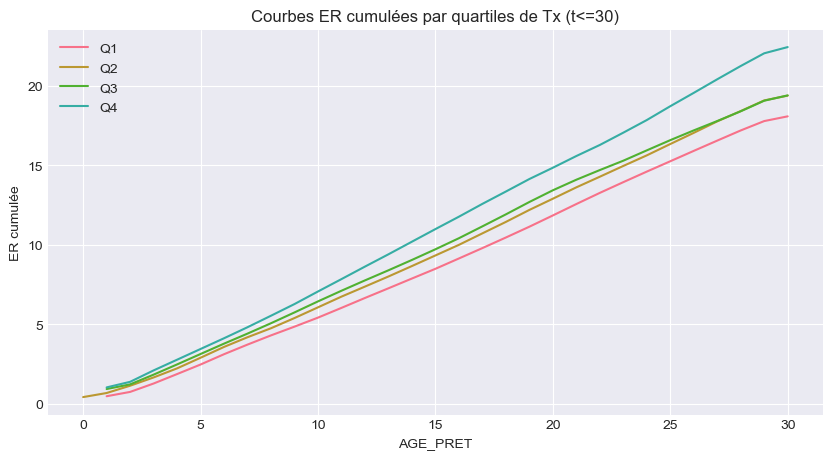

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
for q, sub in agg_f.groupby("tx_q"):
    sub = sub.sort_values("AGE_PRET").copy()
    sub["ER_cum"] = sub["ER"].cumsum()
    sub["ER_cum_s"] = sub["ER_cum"].rolling(3, center=True, min_periods=1).mean()
    plt.plot(sub["AGE_PRET"], sub["ER_cum_s"], label=f"{q}")

plt.title("Courbes ER cumulées par quartiles de Tx (t<=30)")
plt.xlabel("AGE_PRET")
plt.ylabel("ER cumulée")
plt.grid(True)
plt.legend()
plt.show()

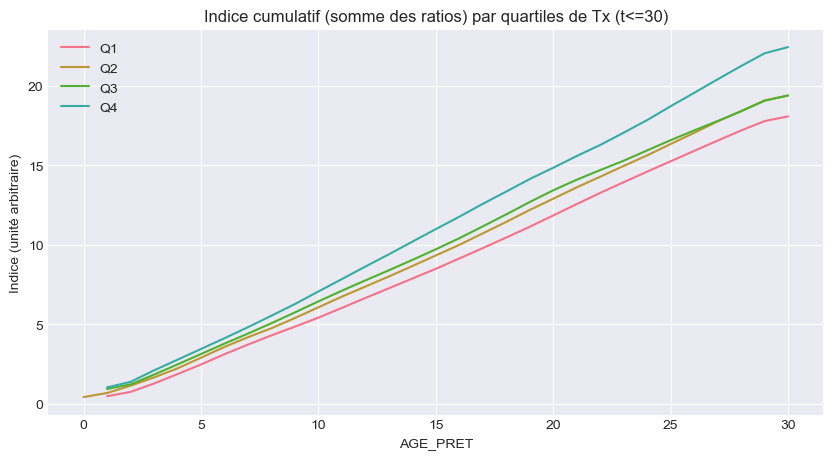

In [40]:
# au lieu de ER_cum, on appelle ça "Indice" pour éviter l'abus d'interprétation
plt.figure(figsize=(10,5))
for q, sub in agg_f.groupby("tx_q"):
    sub = sub.sort_values("AGE_PRET").copy()
    sub["indice"] = sub["ER"].cumsum()
    sub["indice_s"] = sub["indice"].rolling(3, center=True, min_periods=1).mean()
    plt.plot(sub["AGE_PRET"], sub["indice_s"], label=f"{q}")

plt.title("Indice cumulatif (somme des ratios) par quartiles de Tx (t<=30)")
plt.xlabel("AGE_PRET")
plt.ylabel("Indice (unité arbitraire)")
plt.grid(True)
plt.legend()
plt.show()